In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist_ubyte
from tqdm import tqdm

(60000, 784) (60000,)
(10000, 784) (10000,)


In [2]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [ ]:
def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / (np.sum(exp_z, axis=1, keepdims=True) + 1e-8)

In [4]:
def forward(A, B, x):
    O = A.dot(x) + B[0]  # reshape(-1) pour obtenir un vecteur de forme (10,)
    return softmax(O)

In [ ]:
def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

In [6]:
def log_loss(act, y_true):
    eps = 1e-15
    act_clipped = np.clip(act, eps, 1 - eps)
    return -np.sum(y_true * np.log(act_clipped))

In [ ]:
def train(A, B, x_train, y_train, epochs=10, lr=0.01):
    N = x_train.shape[0]
    total_iters = epochs * N

    with tqdm(total=total_iters, desc="Training") as pbar:
        for epoch in range(epochs):
            loss = 0.0
            for i in range(N):
                x = x_train[i].reshape(-1, 1)
                y = one_hot(y_train[i], num_classes=10)
                act = forward(A, B, x).reshape(-1, 1)

                dO = act - y
                dA = dO @ x.T
                dB = dO

                A -= lr * dA
                B -= lr * dB

                loss += log_loss(act, y)

                pbar.update(1)
            
            avg_loss = loss / N
            print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f}")
            

In [ ]:
def predict(A, B, x):
    logits = forward(A, B, x)
    return np.argmax(logits)

In [9]:
def get_error(A, B, x_test, y_test):
    Error = np.sum([predict(A, B, x_test[i]) != y_test[i] for i in range(x_test.shape[0])])
    return Error

In [10]:
def get_precision(A, B, x_test, y_test):
    Error = get_error(A, B, x_test, y_test)
    Precision = 1 - Error / x_test.shape[0]
    return Precision

In [11]:
a, b = -2, 2
A = a + (b - a) * np.random.random_sample((10, 784))
B = a + (b - a) * np.random.random_sample((10, 1))
train(A, B, x_train, y_train, epochs=50, lr=0.01)

Training:   2%|▏         | 62635/3000000 [00:03<02:45, 17722.12it/s]

Epoch 1/50 - loss: 1.0987


Training:   4%|▍         | 121886/3000000 [00:06<02:17, 21005.32it/s]

Epoch 2/50 - loss: 0.5730


Training:   6%|▌         | 183063/3000000 [00:09<02:08, 21956.59it/s]

...

Epoch 48/50 - loss: 0.2594


Training:  98%|█████████▊| 2942764/3000000 [02:36<00:02, 22303.05it/s]

Epoch 49/50 - loss: 0.2590


Training: 100%|██████████| 3000000/3000000 [02:39<00:00, 18849.18it/s]

Epoch 50/50 - loss: 0.2586


In [12]:
print("Predicted:", predict(A, B, x_test[0]), "True:", y_test[0])
print("Error:", get_error(A, B, x_test, y_test))
print("Precision:", get_precision(A, B, x_test, y_test))

Predicted: 7 True: 7
Error: 883
Precision: 0.9117


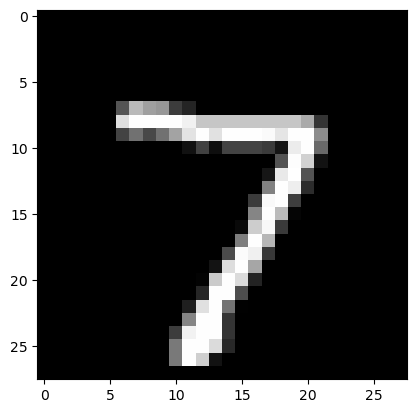

In [13]:
xtest0, ytest0 = x_test[0], y_test[0]
plt.imshow(xtest0.reshape(28, 28), cmap="gray")

In [14]:
predict(A, B, xtest0)

np.int64(7)